In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import category_encoders as ce
import re
from skopt import BayesSearchCV

In [15]:
df = pd.read_csv('train.csv')

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
df.shape

(891, 12)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [25]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
# df['Embarked'].mode()[0]

In [33]:
def preprocess_data(df):
    df = df.drop(['PassengerId', 'Ticket'], axis=1)
    df['family_size'] = df['SibSp'] + df['Parch'] + 1
    df = df.drop(['Parch', 'SibSp'], axis=1)

    df['is_alone'] = df['family_size'].apply(lambda x: 1 if x==1 else 0)

    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

    #fill regression
    age_df = df[['Age', 'Pclass', 'Fare', 'family_size']].copy()
    age_train = age_df.dropna()
    age_test = age_df[age_df['Age'].isnull()]

    reg = LinearRegression()
    reg.fit(age_train.drop('Age', axis=1), age_train['Age']) #x_train, y_train
    predicted_age = reg.predict(age_test.drop('Age', axis=1))
    df.loc[df['Age'].isnull(), 'Age'] = predicted_age

    df['Age'] = pd.cut(df['Age'], bins=[0, 1, 4, 12, 19, 39, 59, 100], labels = [0, 1, 2, 3, 4, 5, 6])
    df['Fare'] = pd.qcut(df['Fare'], 4, labels=[0, 1, 2, 3])

    def get_title(name):
        pattern = re.compile(' ([A-Za-z]+)\.')
        match = pattern.findall(name)
        return match[0] if match else ""

    df['title'] = df['Name'].apply(get_title)
    rare_title = df['title'].value_counts()[df['title'].value_counts() < 10].index
    df['title'] = df['title'].apply(lambda x: 'rare' if x in rare_title else x)
    df = df.drop('Name', axis=1)

    df_encoded = pd.get_dummies(df, drop_first=True)

    return df_encoded

In [35]:
df_encoded = preprocess_data(df)

In [39]:
df_encoded.shape

(891, 166)

In [41]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Columns: 166 entries, Survived to title_rare
dtypes: bool(162), int64(4)
memory usage: 168.9 KB


In [47]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
df_encoded.head()

,Survived,Pclass,family_size,is_alone,Sex_male,Age_1,Age_2,Age_3,Age_4,Age_5,...,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S,title_Miss,title_Mr,title_Mrs,title_rare
0,0,3,2,0,True,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,1,1,2,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,1,3,1,1,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
3,1,1,2,0,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
4,0,3,1,1,True,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False


In [49]:
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

In [51]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
dt_model = DecisionTreeClassifier(random_state=42)

In [55]:
search_spaces_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': (2, 20),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 10)
}

In [57]:
bayes_search_dt = BayesSearchCV(estimator=dt_model, search_spaces=search_spaces_dt, n_iter=32, cv=5,
                               scoring='accuracy', n_jobs=-1, random_state=42)

In [59]:
bayes_search_dt.fit(X_train, y_train)

BayesSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
              n_iter=32, n_jobs=-1, random_state=42, scoring='accuracy',
              search_spaces={'criterion': ['gini', 'entropy'],
                             'max_depth': (2, 20), 'min_samples_leaf': (1, 10),
                             'min_samples_split': (2, 20)})

In [60]:
best_dt = bayes_search_dt.best_estimator_

In [63]:
best_dt

DecisionTreeClassifier(max_depth=8, min_samples_split=19, random_state=42)

In [65]:
cv_scores_dt = cross_val_score(best_dt, X_train, y_train, cv=5)

In [69]:
cv_scores_dt.mean()

0.832837584950261

In [71]:
best_dt.fit(X_train, y_train)
y_val_pred = best_dt.predict(X_val)

In [73]:
y_val_pred

array([1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1], dtype=int64)

In [75]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



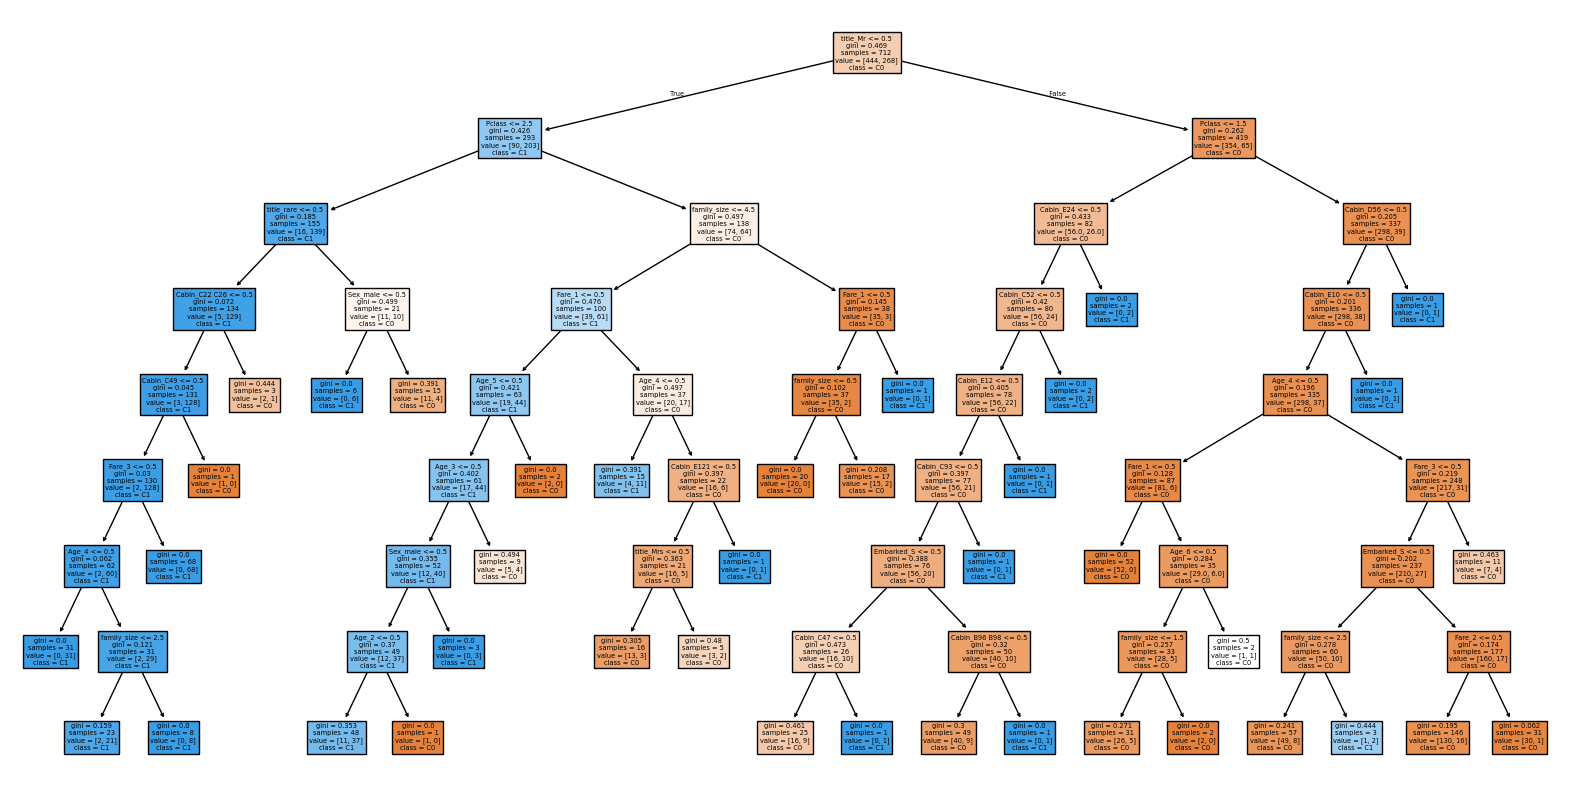

In [85]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt, filled=True, feature_names=X.columns, class_names=['C0', 'C1'])
plt.show()

In [77]:
rf_model = RandomForestClassifier(random_state=42)

In [87]:
search_spaces_rf = {
    'n_estimators': (100, 300),
    'max_depth': (10, 30),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 10),
    'bootstrap': [True, False]
}

In [89]:
bayes_search_rf = BayesSearchCV(estimator=rf_model, search_spaces=search_spaces_rf, n_iter=32, cv=5, 
                                scoring='accuracy', n_jobs=-1, random_state=42)

In [91]:
bayes_search_rf.fit(X_train, y_train)

BayesSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
              n_iter=32, n_jobs=-1, random_state=42, scoring='accuracy',
              search_spaces={'bootstrap': [True, False], 'max_depth': (10, 30),
                             'min_samples_leaf': (1, 10),
                             'min_samples_split': (2, 10),
                             'n_estimators': (100, 300)})

In [92]:
best_rf = bayes_search_rf.best_estimator_

In [93]:
cv_scores_rf = cross_val_score(best_rf, X_train, y_train, cv=5)
cv_scores_rf

array([0.85314685, 0.85314685, 0.79577465, 0.80985915, 0.84507042])

In [97]:
best_rf.fit(X_train, y_train)
y_val_pred_rf = best_rf.predict(X_val)

In [99]:
print(classification_report(y_val, y_val_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [109]:
FI = best_rf.feature_importances_
np.sort(FI)

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 7.13550640e-06, 1.76163976e-05,
       1.89092193e-05, 2.41693905e-05, 3.50626025e-05, 4.03065400e-05,
       4.08086063e-05, 4.72080864e-05, 5.09874537e-05, 5.18294401e-05,
       5.45245008e-05, 5.45619997e-05, 5.76010459e-05, 6.06039795e-05,
       6.49005987e-05, 6.70262255e-05, 7.41824522e-05, 7.69583423e-05,
       7.73849562e-05, 8.10196314e-05, 8.31297567e-05, 8.63118285e-05,
       8.82393643e-05, 8.96056600e-05, 9.12923892e-05, 9.30006629e-05,
      

In [111]:
df_test = pd.read_csv('test.csv')

In [113]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [115]:
df_t = preprocess_data(df_test)

In [117]:
df_t

,Pclass,family_size,is_alone,Sex_male,Age_1,Age_2,Age_3,Age_4,Age_5,Age_6,...,Cabin_F2,Cabin_F33,Cabin_F4,Cabin_G6,Embarked_Q,Embarked_S,title_Miss,title_Mr,title_Mrs,title_rare
0,3,1,1,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
1,3,2,0,False,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
2,2,1,1,True,False,False,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
3,3,1,1,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
4,3,3,0,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,1,1,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
414,1,1,1,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
415,3,1,1,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
416,3,1,1,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False


In [119]:
df_encoded

,Survived,Pclass,family_size,is_alone,Sex_male,Age_1,Age_2,Age_3,Age_4,Age_5,...,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S,title_Miss,title_Mr,title_Mrs,title_rare
0,0,3,2,0,True,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,1,1,2,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,1,3,1,1,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
3,1,1,2,0,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
4,0,3,1,1,True,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,1,True,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
887,1,1,1,1,False,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
888,0,3,4,0,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
889,1,1,1,1,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [121]:
missing_cols = set(X_train.columns) - set(df_t.columns)

for col in missing_cols:
    df_t[col] = 0
df_t = df_t[X_train.columns]

C:\Users\Asus\AppData\Local\Temp\ipykernel_42508\1590065002.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_t[col] = 0
C:\Users\Asus\AppData\Local\Temp\ipykernel_42508\1590065002.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_t[col] = 0
C:\Users\Asus\AppData\Local\Temp\ipykernel_42508\1590065002.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.

In [123]:
predictions = best_dt.predict(df_t)

In [125]:
sub = pd.DataFrame({
    'PassengerId': pd.read_csv('test.csv')['PassengerId'],
    'Survived': predictions   
})

In [127]:
sub.to_csv('Submission.csv', index=False)